## Normal Bezier ##

In [6]:
import numpy as np
import math
t = np.linspace(0,1,100)
n=2
points_P = [[0.25,1,48], [100,14,49], [1000,26,66], [100,42,51], [0.25,54,49]]
points_QRS = [[0.5,57,46], [200,65,31], [1500,74,154], [100,86,22], [0.25,97,44]]
points_T = [[0.15,109,48], [100,122,51], [1000,141,84], [200,156,51], [0.15,174,49]]

def polynomial(n,t,P):
    B_funcs = np.zeros([n+1,len(t)])
    for i in range(n+1):
        comb = math.comb(n,i)
        B_i = P[i]*comb*(t**i)*(1-t)**(n-i)
        B_funcs[i,:]= B_i
    B_polynomial = np.sum(B_funcs,axis=0)
    return B_polynomial

polynomial_n = polynomial(n,t,points_P)



ValueError: operands could not be broadcast together with shapes (3,) (100,) 

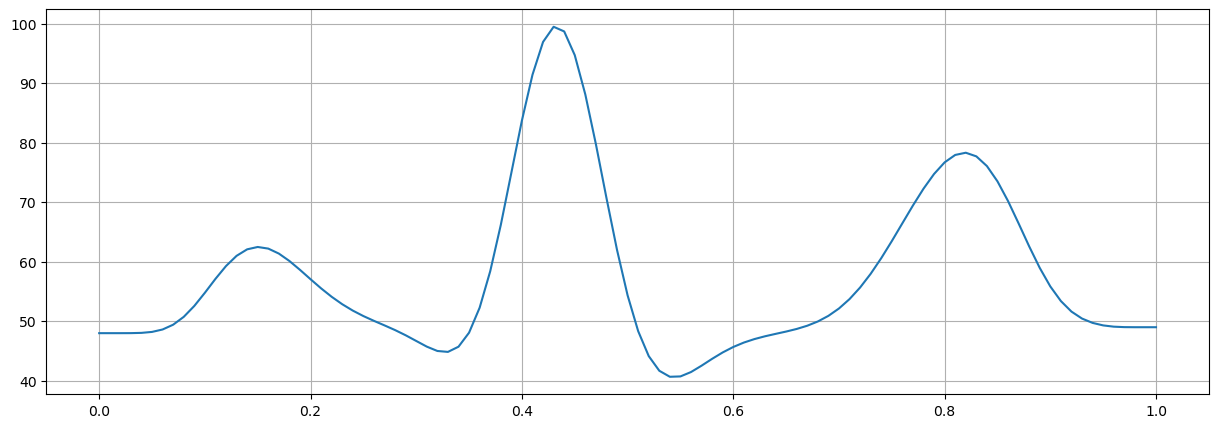

In [64]:
plt.figure(figsize=(15,5))
plt.plot(t,polynomial_n)

plt.grid()

## Rational Bezier ##

In [7]:
import numpy as np 
import matplotlib.pyplot as plt
import math 

points_P = [[0.25,1,48], [100,14,49], [1000,26,66], [100,42,51], [0.25,54,49]]
points_QRS = [[0.5,57,46], [200,65,31], [1500,74,154], [100,86,22], [0.25,97,44]]
points_T = [[0.15,109,48], [100,122,51], [1000,141,84], [200,156,51], [0.15,174,49]]

P = [[0.25,1,48], [100,14,49], [1000,26,66], [100,42,51], [0.25,54,49], [0.5,57,46], [200,65,31], [1500,74,154], [100,86,22], [0.25,97,44], [0.15,109,48], [100,122,51], [1000,141,84], [200,156,51], [0.15,174,49]]
n = 4
t = np.linspace(0,1,101)


In [8]:
def b_polynomial(t,P):
    n = len(P)-1
    num_x = np.zeros([n+1,len(t)])
    num_y = np.zeros([n+1,len(t)])
    denom = np.zeros([n+1, len(t)])

    for i in range(n+1):
        w = P[i][0]
        x = P[i][1]
        y = P[i][2]
        comb = math.comb(n,i)
        B_i = comb*(t**i)*(1-t)**(n-i)
        num_x[i,:]= B_i*w*x
        num_y[i,:]=B_i*w*y
        denom[i,:]=B_i*w
    B_x = np.sum(num_x,axis=0)
    B_y = np.sum(num_y,axis=0)
    B_denom = np.sum(denom, axis=0)
    return B_x/B_denom, B_y/B_denom 

Px,Py = b_polynomial(t,points_P)
QRSx,QRSy = b_polynomial(t,points_QRS)
Tx,Ty = b_polynomial(t,points_T)
a,b = b_polynomial(t, P)

x = np.concatenate((Px, QRSx, Tx),axis=0)
y = np.concatenate((Py,QRSy,Ty),axis=0)


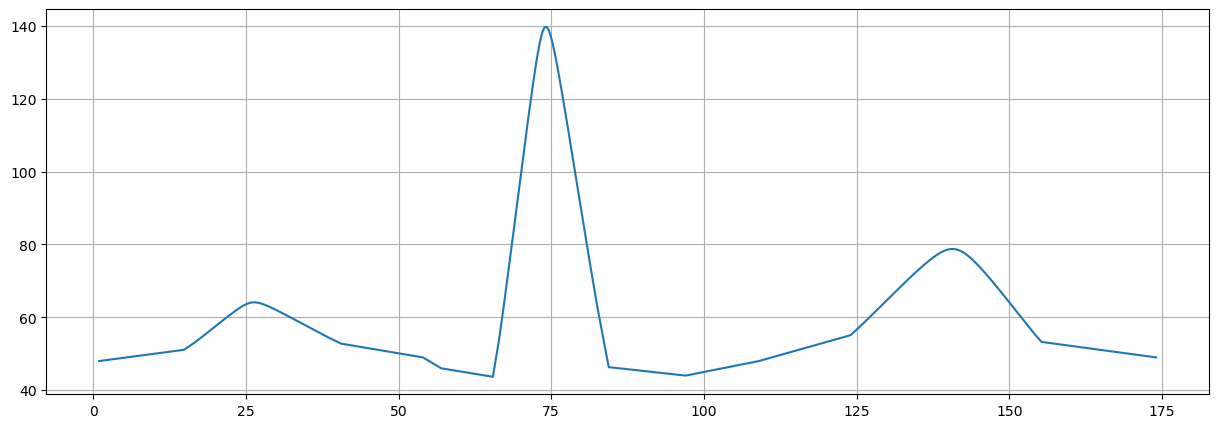

In [9]:

plt.figure(figsize=(15,5))
plt.plot(x,y)
plt.grid()

## Using Desmos to find better points to make a clearer trace ##

In [10]:
points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
points_P = [[10,3.5,0],[1,4,0.3],[2,5,0.9],[20,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[10,8,0]]
points_preQRS = [[1,8.25,0],[1,8.5,0],[1,8.75,0],[1,9,0],[1,9.25,0],[1,9.5,0],[1,10,0]]
points_QRS = [[10,10.3,0],[500,11.1,-1.5],[10,11.25,0],[1000,12,11],[10,12.65,0],[500,12.85,-3.3],[10,13.7,0]]
points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
points_T = [[10,17,0],[1,18,1],[2,19,1.9],[20,19.6,2.1],[2,21,0.55],[10,21.4,0]]
points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]



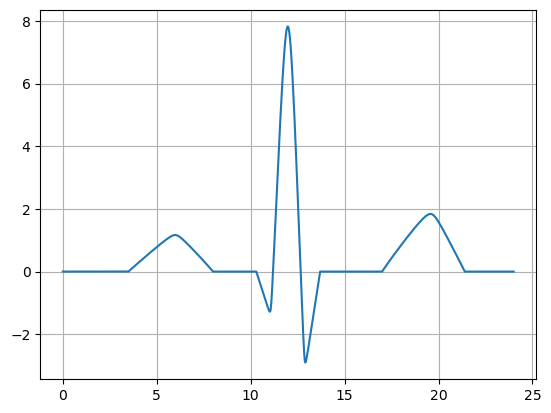

In [11]:
prePx,prePy = b_polynomial(t,points_preP)
Px,Py = b_polynomial(t,points_P)
preQRSx,preQRSy = b_polynomial(t,points_preQRS)
QRSx,QRSy = b_polynomial(t, points_QRS)
preTx, preTy = b_polynomial(t, points_preT)
Tx,Ty = b_polynomial(t, points_T)
postTx, postTy = b_polynomial(t, points_postT)

x = np.concatenate((prePx, Px, preQRSx,QRSx, preTx, Tx, postTx),axis=0)
y = np.concatenate((prePy,Py,preQRSy, QRSy, preTy, Ty, postTy),axis=0)

plt.plot(x,y)
plt.grid()


## Simulating ventricular pacing ##

In [12]:
points_P = [[0.25,1,48], [100,14,49], [1000,26,66], [100,42,51], [0.25,48,49]]
points_pacemaker = [[1000,55.3,48],[1500, 56,120],[1000,55.8,48]]
points_QRS = [[200,60,46], [200,70,-31], [1000,74,-120], [100,80,-22], [0.25,92,44]]
points_T = [[0.15,109,48], [100,122,51], [1000,141,84], [200,156,51], [0.15,174,49]]

n = 4
t = np.linspace(0,1,101)

In [13]:
points_P = [[10,1,48], [50,14,49], [80,26,66], [50,42,51], [10,48,49]]
points_pacemaker = [[20000,55.3,48],[80000, 56,120],[20000,55.8,48]]
points_QRS = [[15000,60,46], [15000,70,-31], [5000,74,-120], [1500,80,-22], [1200,92,44]]
points_T = [[40,109,48], [120,122,51], [300,141,84], [120,156,51], [40,174,49]]

n = 4
t = np.linspace(0,1,101)

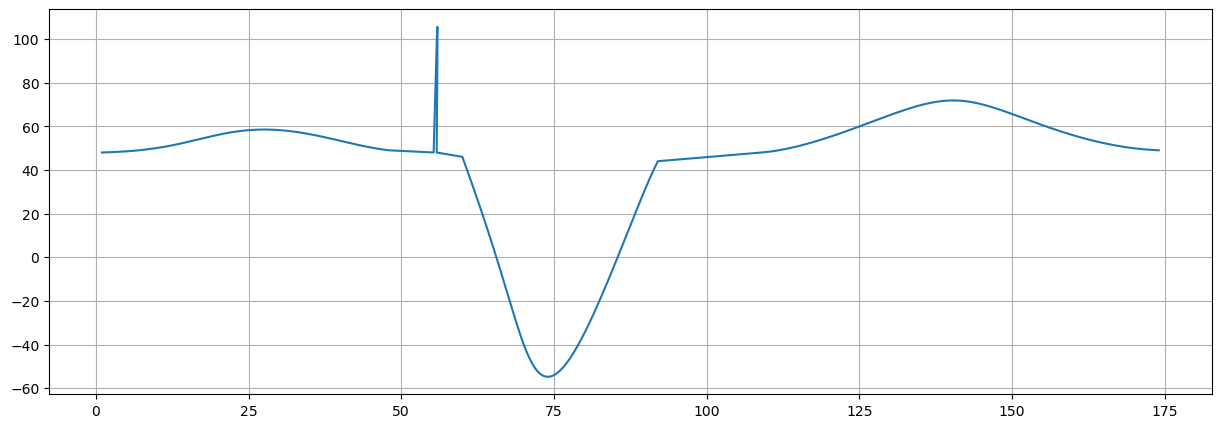

In [14]:
Px,Py = b_polynomial(t,points_P)
QRSx,QRSy = b_polynomial(t,points_QRS)
Tx,Ty = b_polynomial(t,points_T)
pacemaker_x, pacemaker_y = b_polynomial(t, points_pacemaker)

x = np.concatenate((Px, pacemaker_x, QRSx, Tx),axis=0)
y = np.concatenate((Py,pacemaker_y,QRSy,Ty),axis=0)

figure = plt.figure(figsize=(15,5))
plt.plot(x,y)
plt.grid()

In [15]:
points_preP = [[1,0,0],[1,1,0],[1,2,0],[1,2.5,0]]
points_P = [[10,2.9,0],[5,3.6,0.7],[15,4.15,0.9],[15,4.25,0.9],[5,4.7,0.7],[10,5.4,0]]
points_prePacemaker = [[1,5.5,0],[1,6,0],[1,7,0],[1,8,0]]
points_Pacemaker = [[1,8.3,0],[5,8.4,8],[1,8.5,0]]
points_QRS = [[2,9,-0.8],[1,9.5,-3.1],[5,9.9,-7.1],[5,10.2,-7.6],[1,10.5,-11.5],[10,11.05,-16.8],[1,11.5,-14.6],[1,12,-10.5],[1,12.5,-6.4],[1,13,-3],[10,13.6,0]]
points_T = [[10,13.61,0],[1,13.8,0.4],[1,14,0.75],[1,14.5,1.8],[1,15,2.75],[1,15.5,3.6],[1,16,4.15],[5,16.5,4.75],[5,17,5.4],[15,17.45,5.7],[5,18,5.3],[5,18.5,4.4],[1,19,3],[1,19.5,1.6],[1,20,0.5],[1,20.4,0]]
points_postT = [[1,21,0],[1,22,0],[1,23,0],[1,24,0],[1,25,0]]


### Desmos to find points ###

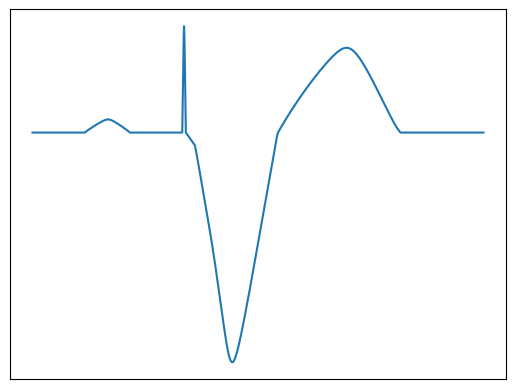

In [ ]:
import matplotlib.pyplot as plt 

prePx,prePy = b_polynomial(t,points_preP)
Px,Py = b_polynomial(t,points_P)
prePacemakerx, prePacemakery = b_polynomial(t,points_prePacemaker)
Pacemakerx, Pacemakery = b_polynomial(t,points_Pacemaker)
QRSx,QRSy = b_polynomial(t, points_QRS)
Tx,Ty = b_polynomial(t, points_T)
postTx, postTy = b_polynomial(t, points_postT)

x = np.concatenate((prePx, Px, prePacemakerx, Pacemakerx, QRSx, Tx, postTx),axis=0)
y = np.concatenate((prePy,Py,prePacemakery, Pacemakery, QRSy, Ty, postTy),axis=0)

plt.plot(x,y)
plt.xticks([])
plt.yticks([])
plt.grid()





In [1]:
def ECG_wave(signal_type):
    #Checking signal type 
    if signal_type == 'Normal':
       points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
       points_P = [[10,3.5,0],[1,4,0.3],[2,5,0.9],[20,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[10,8,0]]
       points_preQRS = [[1,8.25,0],[1,8.5,0],[1,8.75,0],[1,9,0],[1,9.25,0],[1,9.5,0],[1,10,0]]
       points_QRS = [[10,10.3,0],[500,11.1,-1.5],[10,11.25,0],[1000,12,11],[10,12.65,0],[500,12.85,-3.3],[10,13.7,0]]
       points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
       points_T = [[10,17,0],[1,18,1],[2,19,1.9],[20,19.6,2.1],[2,21,0.55],[10,21.4,0]]
       points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
       
       prePx,prePy = b_polynomial(t,points_preP)
       Px,Py = b_polynomial(t,points_P)
       preQRSx,preQRSy = b_polynomial(t,points_preQRS)
       QRSx,QRSy = b_polynomial(t, points_QRS)
       preTx, preTy = b_polynomial(t, points_preT)
       Tx,Ty = b_polynomial(t, points_T)
       postTx, postTy = b_polynomial(t, points_postT)
       
       x = np.concatenate((prePx, Px, preQRSx,QRSx, preTx, Tx, postTx),axis=0)
       y = np.concatenate((prePy,Py,preQRSy, QRSy, preTy, Ty, postTy),axis=0)
       
 
    elif signal_type == "Ventricular pacing":
        points_preP = [[1,0,0],[1,1,0],[1,2,0],[1,2.5,0]]
        points_P = [[10,2.9,0],[5,3.6,0.7],[15,4.15,0.9],[15,4.25,0.9],[5,4.7,0.7],[10,5.4,0]]
        points_prePacemaker = [[1,5.5,0],[1,6,0],[1,7,0],[1,8,0]]
        points_Pacemaker = [[1,8.3,0],[5,8.4,10],[1,8.5,0]]
        points_QRS = [[2,9,-0.8],[1,9.5,-3.1],[5,9.9,-7.1],[5,10.2,-7.6],[1,10.5,-11.5],[10,11.05,-16.8],[1,11.5,-14.6],[1,12,-10.5],[1,12.5,-6.4],[1,13,-3],[10,13.6,0]]
        points_T = [[10,13.61,0],[1,13.8,0.4],[1,14,0.75],[1,14.5,1.8],[1,15,2.75],[1,15.5,3.6],[1,16,4.15],[5,16.5,4.75],[5,17,5.4],[15,17.45,5.7],[5,18,5.3],[5,18.5,4.4],[1,19,3],[1,19.5,1.6],[1,20,0.5],[1,20.4,0]]
        points_postT = [[1,21,0],[1,22,0],[1,23,0],[1,24,0],[1,25,0]]

        prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        prePacemakerx, prePacemakery = b_polynomial(t,points_prePacemaker)
        Pacemakerx, Pacemakery = b_polynomial(t,points_Pacemaker)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        Tx,Ty = b_polynomial(t, points_T)
        postTx, postTy = b_polynomial(t, points_postT)

        x = np.concatenate((prePx, Px, prePacemakerx, Pacemakerx, QRSx, Tx, postTx),axis=0)
        y = np.concatenate((prePy,Py,prePacemakery, Pacemakery, QRSy, Ty, postTy),axis=0)

    return x,y

    


In [ ]:
# Function to space beats according to patient HR
def heart_rate(patient_HR):
    '''
    Calculates the gap between beats based on patient heart rate in bpm
    Note: assumes all heart beats are exactly the same (based on standard heartbeat defined in ECG_wave function)
    only gives give that results in approximately patient_HR
    '''
    gap = (1500)*(0.04)/patient_HR - 0.4007574025940901 - 0.39924259740590995
    return gap



In [ ]:
# Function to choose beat list based on sensitivity and rate (assuming capture for now)
#This will have to be done simulatenously with running the stitch beats function somehow
def beat_selection(sensitivity, rate, signal):
    if sensitivity > np.max(signal):


In [ ]:
def stitch_beats(ecg_func, beat_list, gap, regularity):
    offset = 0 
    
    for i, signal in enumerate(beat_list):
        x_temp, y_temp = ecg_func(signal)
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Apply offset for next beat
            offset = np.max(x_temp)
            print(np.argmax(y_temp))
            print(x[352])
            #dist from start of signal to R-peak
            print(f"Distance from start of signal to R-peak: {x[352]-x[0]}")
            #dist from R-peak to end of signal
            print(f"Distance from R-peak to end of signal: {x[-1]-x[352]}")
        else:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y
            if regularity == 'Irregular':
                gap = gap + np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap
            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)
    return x, y

In [ ]:
def stitch_beats_new(ecg_func, beat_list, gap, regularity, sensitivity,rate):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type
    beat_list: list of signal types to be stitched together. As input should be ['Normal'] 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker
    rate: programmed rate of pacemaker
    '''
    offset = 0 

    for i in range(10):
        #Need to edit function, should be based on both rate determined at certain sensitivity
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Apply offset for next beat
            offset = np.max(x_temp)

            #Determine next beat type based on sensitivity
            if np.max(y_temp) < sensitivity:
                beat_list.append("Ventricular pacing")
                beat_list.append("Normal")

            else:
                beat_list.append('Normal')

        else: #Second beat onwards
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap = gap + np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity:
                beat_list.append("Ventricular pacing")
                beat_list.append("Normal")

            else:
                beat_list.append('Normal')


    return x, y


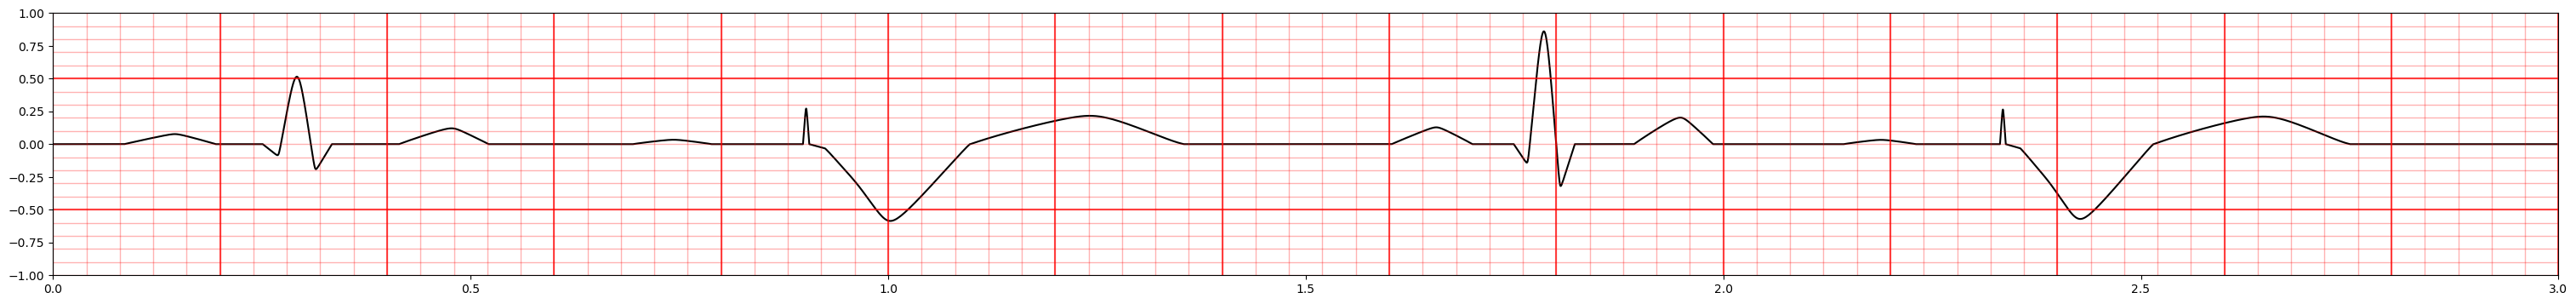

In [309]:
beats = ['Normal']
patient_HR = 75
gap = heart_rate(patient_HR)
x_ecg, y_ecg = stitch_beats_new(ECG_wave, beats, gap, regularity='Regular', sensitivity=1.7, rate=80)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 3)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

352
0.41612563679215797
Distance from start of signal to R-peak: 0.41612563679215797
Distance from R-peak to end of signal: 0.41770449956292244


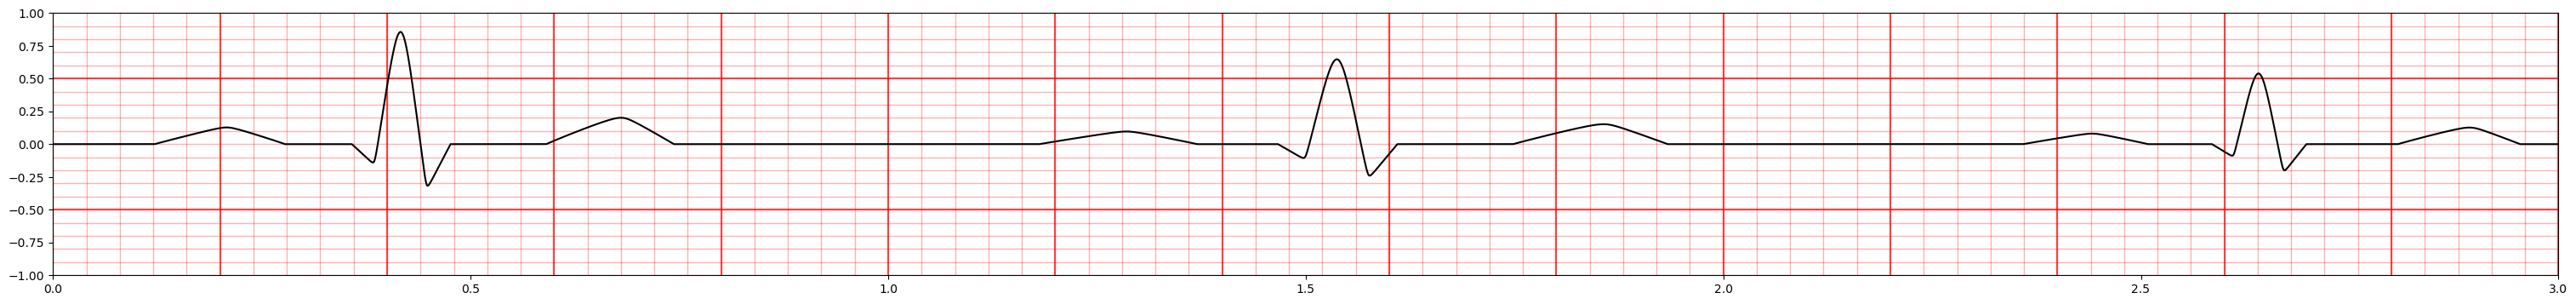

In [202]:
beats = ['Normal']*6
patient_HR = 60
gap = heart_rate(patient_HR)
x_seq, y_seq = stitch_beats(ECG_wave, beats, gap, regularity='Regular')
fig = plt.figure(figsize=(38,4))
plt.xlim(0, 3)
plt.ylim(-1, 1)
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
for ii in range(len(big_lines_v)):
    plt.axvline(x=big_lines_v[ii], color='red', alpha=0.7, lw=1.5)
for ii in range (len(small_lines_v)):
    plt.axvline(x=small_lines_v[ii], color='red', alpha=0.3, lw=1)
big_lines_h = np.arange(-1.5, 1.5, 1)
for ii in range(len(big_lines_h)):
    plt.axhline(y=big_lines_h[ii], color='red', alpha=0.7, lw=1.5)
small_lines_h = np.arange(-1.5, 1.5, 0.1)
for ii in range (len(small_lines_h)):
    plt.axhline(y=small_lines_h[ii], color='red', alpha=0.3, lw=1)
plt.plot(x_seq, y_seq, color='black')


352
0.3669093175148906
Distance from start of signal to R-peak: 0.3669093175148906
Distance from R-peak to end of signal: 0.3683014438595604


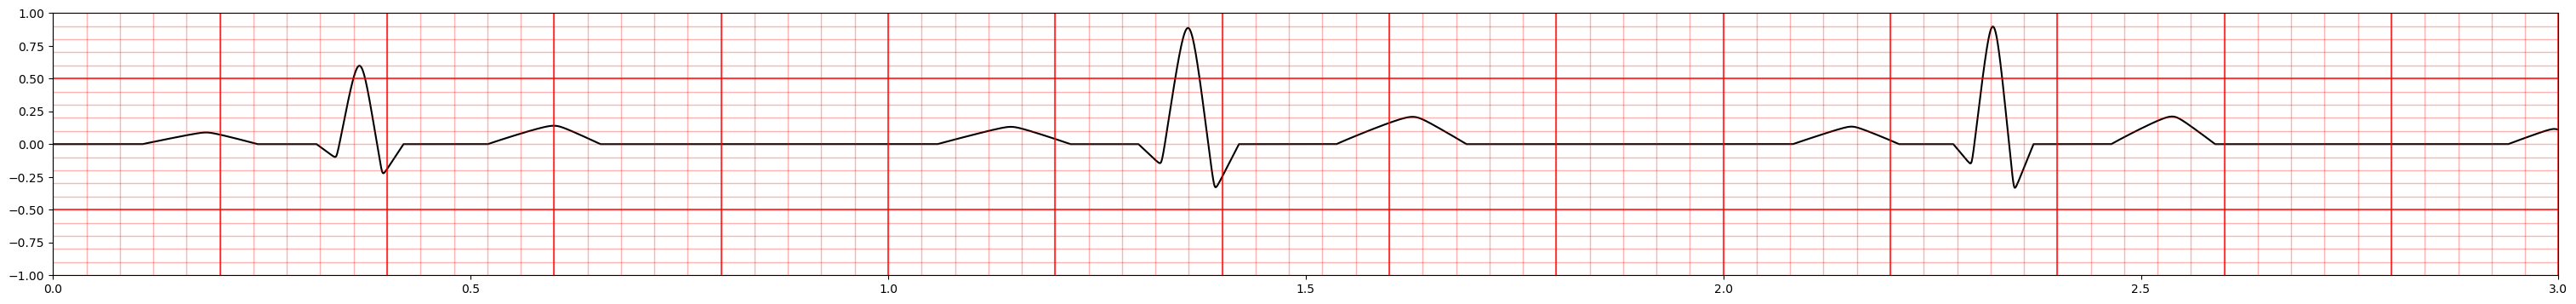

In [204]:
beats = ['Normal']*6
patient_HR = 60
gap = heart_rate(patient_HR)
x_seq, y_seq = stitch_beats(ECG_wave, beats, gap, regularity='Regular')

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_seq, y_seq, color='black')
ax.set_xlim(0, 3)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)